In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Comment Category Prediction

This project aims to classify user comments into one of four categories using textual, numerical, and categorical features.

Dataset includes:
- Text (comment)
- Metadata (votes, emoticons)
- Sensitive attributes (race, religion, gender)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")

All imports successful


# Data Loading

In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (198000, 15)
Test shape: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


# Exploratory data analysis

=== Label Distribution ===
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64
label
0    0.577
2    0.315
1    0.080
3    0.028
Name: proportion, dtype: float64


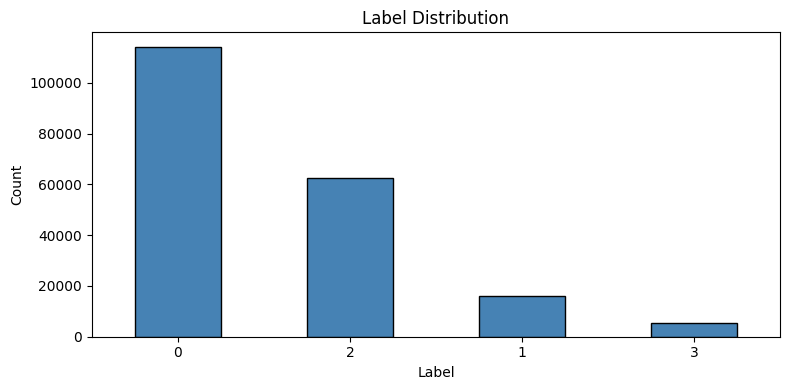


=== Missing Values ===
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

=== Numeric Feature Stats ===
             post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390       1.023234       0.258477       0.481013   
min        20.000000       0.000000       0.000000       0.000000   
25%        39.000000       0.000000       0.000000       0.000000   
50%        72.000000       0.000000       0.000000       0.000000   
75%        72.000000       0.000000       0.000000       0.000000   
max       129.000000      47.000000

In [4]:
# Class distribution
print("=== Label Distribution ===")
print(train["label"].value_counts())
print(train["label"].value_counts(normalize=True).round(3))

plt.figure(figsize=(8,4))
train["label"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Missing values
print("\n=== Missing Values ===")
print(train.isnull().sum())

# Numeric stats
print("\n=== Numeric Feature Stats ===")
print(train.describe())

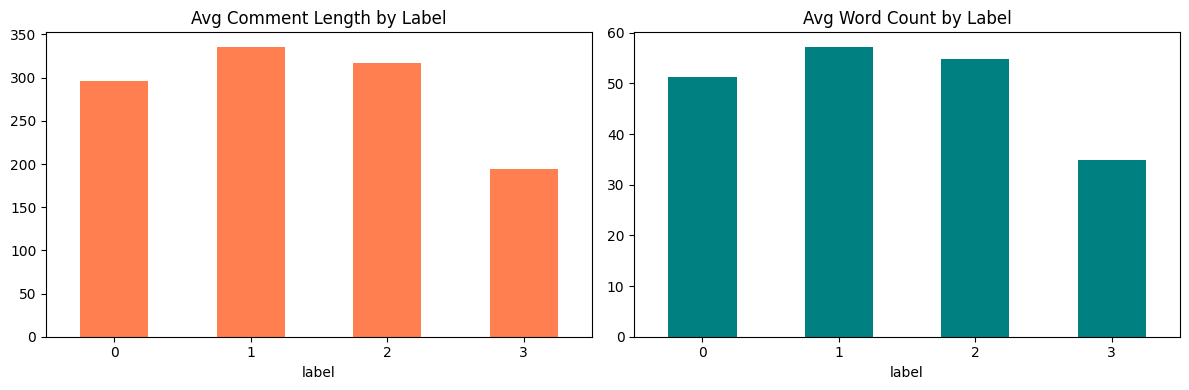

In [5]:
# Comment length analysis
train["comment_len"] = train["comment"].fillna("").apply(len)
train["word_count"]  = train["comment"].fillna("").apply(lambda x: len(x.split()))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
train.groupby("label")["comment_len"].mean().plot(kind="bar", color="coral")
plt.title("Avg Comment Length by Label")
plt.xticks(rotation=0)

plt.subplot(1,2,2)
train.groupby("label")["word_count"].mean().plot(kind="bar", color="teal")
plt.title("Avg Word Count by Label")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation:

In [6]:
print("""
- Different labels show variation in comment length
- Text features may be useful
""")


- Different labels show variation in comment length
- Text features may be useful




race value counts:
 race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

religion value counts:
 religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

gender value counts:
 gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64

disability value counts:
 disability
False    195257
True       2743
Name: count, dtype: int64


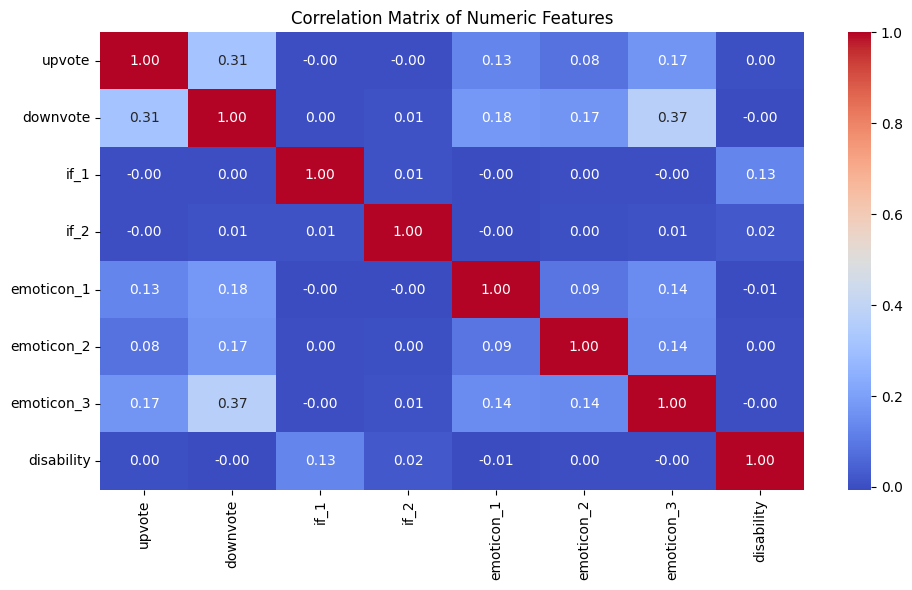

In [7]:
# Categorical feature analysis
for col in ["race", "religion", "gender", "disability"]:
    print(f"\n{col} value counts:\n", train[col].value_counts())

# Correlation heatmap for numeric features
numeric_cols = ["upvote", "downvote", "if_1", "if_2", 
                "emoticon_1", "emoticon_2", "emoticon_3", "disability"]
plt.figure(figsize=(10,6))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

### Observations:

In [8]:
print("""
- Weak correlations among numeric features
- Indicates text features will be more important
""")


- Weak correlations among numeric features
- Indicates text features will be more important



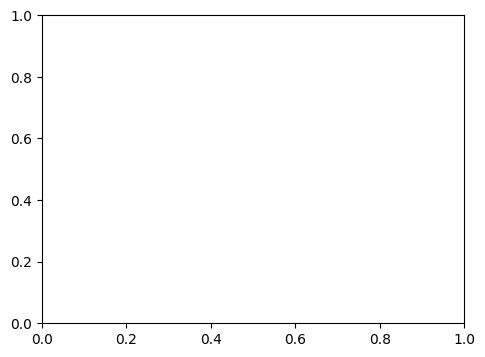

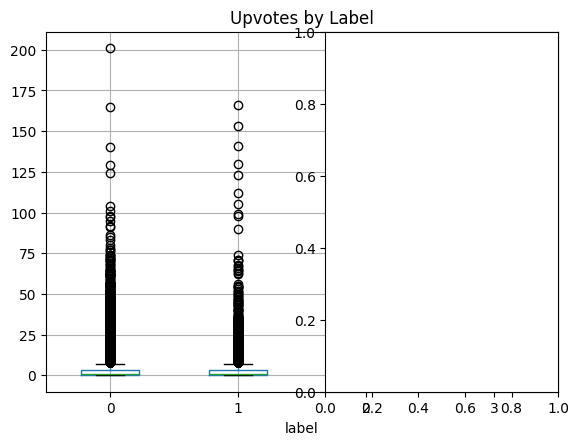

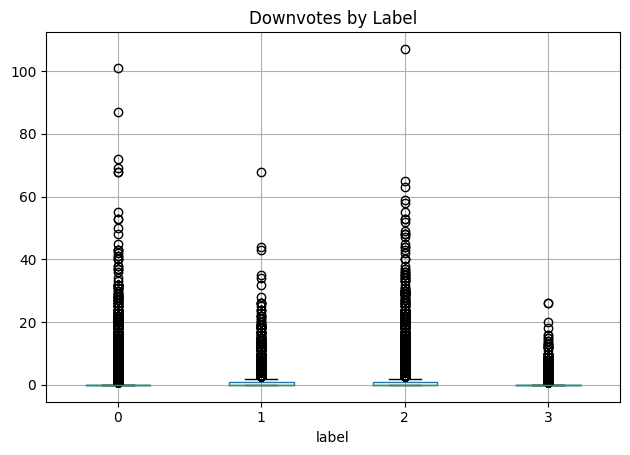

In [9]:
# Upvote/downvote by label
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
train.boxplot(column="upvote", by="label")
plt.title("Upvotes by Label")
plt.suptitle("")

plt.subplot(1,2,2)
train.boxplot(column="downvote", by="label")
plt.title("Downvotes by Label")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Observations:

In [10]:
print("""
- Dataset is highly imbalanced (class 0 dominates)
- Class 3 is very small → harder to predict
""")


- Dataset is highly imbalanced (class 0 dominates)
- Class 3 is very small → harder to predict



### Key Insights from EDA

- The dataset is highly imbalanced, with label 0 dominating (~57%).
- Label 3 has very few samples, making it harder for models to learn.
- Text-based features (comments) are the most informative for prediction.
- Numeric features like upvotes and downvotes show some correlation with labels.
- Categorical features contain many missing values and are sparse.

In [11]:
# Handle missing categorical values
for col in ["race", "religion", "gender"]:
    train[col] = train[col].fillna("unknown")
    test[col]  = test[col].fillna("unknown")

# Text already handled later, but we mention it
train["comment"] = train["comment"].fillna("")
test["comment"]  = test["comment"].fillna("")

### Missing Value Handling

- The dataset contains a large number of missing values in categorical features such as race, religion, and gender.
- These missing values are treated as a separate category using `SimpleImputer(strategy="constant", fill_value="unknown")`.
- For numerical features, missing values are replaced using the median.
- This ensures no data leakage and consistent preprocessing through pipelines.

In [12]:
print("""
- race, religion, gender have large missing values
- Will require imputation
""")


- race, religion, gender have large missing values
- Will require imputation



### Feature Types

- Text Feature:
  - comment

- Categorical Features:
  - race, religion, gender

- Numerical Features:
  - upvote, downvote, if_1, if_2, emoticons

- Boolean:
  - disability

# Feature Engineering

#### We create new features from text, date, and interaction signals to improve model performance.

In [13]:
def preprocess(df):
    df = df.copy()
    
    # Fill missing text
    df["comment"] = df["comment"].fillna("")
    
    # Date features
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["day"]       = df["created_date"].dt.day
    df["month"]     = df["created_date"].dt.month
    df["year"]      = df["created_date"].dt.year
    df["dayofweek"] = df["created_date"].dt.dayofweek
    df["hour"]      = df["created_date"].dt.hour
    df["is_weekend"]= (df["dayofweek"] >= 5).astype(int)
    df["quarter"]   = df["created_date"].dt.quarter
    df.drop(columns=["created_date"], inplace=True)
    
    # TEXT-BASED FEATURES
    df["comment_len"]  = df["comment"].apply(len)
    df["word_count"]   = df["comment"].apply(lambda x: len(x.split()))
    
    df["avg_word_len"] = df["comment"].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    df["char_per_word"] = df["comment_len"] / (df["word_count"] + 1)
    
    # punctuation
    df["exclamation"]    = df["comment"].apply(lambda x: x.count("!"))
    df["question_marks"] = df["comment"].apply(lambda x: x.count("?"))
    
    # punctuation density (very useful)
    df["punct_ratio"] = (df["exclamation"] + df["question_marks"]) / (df["comment_len"] + 1)
    
    # caps
    df["caps_ratio"] = df["comment"].apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1)
    )
    
    # digit presence
    df["has_number"] = df["comment"].str.contains(r"\d").astype(int)
    
    # URL presence (toxic / spam indicator)
    df["has_url"] = df["comment"].str.contains(r"http|www", case=False, regex=True).astype(int)
    
    # lexical diversity
    df["unique_words"] = df["comment"].apply(lambda x: len(set(x.lower().split())))
    df["lexical_diversity"] = df["unique_words"] / (df["word_count"] + 1)
    
    # INTERACTION FEATURES
    
    df["vote_ratio"]  = df["upvote"] / (df["downvote"] + 1)
    df["vote_diff"]   = df["upvote"] - df["downvote"]
    df["total_votes"] = df["upvote"] + df["downvote"]
    df["emoticon_total"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]
    
    # sensitive flags
    df["sensitive_flags"] = df[["race","religion","gender"]].apply(
        lambda r: sum([x not in ["none", "unknown"] for x in r]), axis=1
    )
    
    return df

train = preprocess(train)
test  = preprocess(test)

print("Train shape after feature engineering:", train.shape)
train.head(3)

Train shape after feature engineering: (198000, 38)


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,...,caps_ratio,has_number,has_url,unique_words,lexical_diversity,vote_ratio,vote_diff,total_votes,emoticon_total,sensitive_flags
0,73,0,0,0,0,1,0,10,unknown,unknown,...,0.016807,0,0,19,0.904762,0.0,-1,1,0,0
1,39,0,0,0,6,0,0,4,unknown,unknown,...,0.013953,0,0,71,0.639640,6.0,6,6,0,0
2,31,0,1,1,0,0,0,10,unknown,unknown,...,0.017287,1,0,95,0.708955,0.0,0,0,2,0


In [14]:
for df in [train, test]:
    df["has_exclamation"] = df["comment"].str.contains("!").astype(int)
    df["has_question"]    = df["comment"].str.contains(r"\?").astype(int)
    df["has_caps"]        = df["comment"].str.contains(r"[A-Z]{3,}", regex=True).astype(int)

### Train-test split  

In [15]:
# Drop post_id as it's just an identifier
drop_cols = ["post_id"] if "post_id" in train.columns else []

X = train.drop(["label"] + drop_cols, axis=1)
y = train["label"]

# Drop post_id from test too
if "post_id" in test.columns:
    test = test.drop(columns=["post_id"])

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
test = test.reset_index(drop=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Class balance:\n", y_train.value_counts(normalize=True))

X_train: (158400, 39)
X_val: (39600, 39)
Class balance:
 label
0    0.576629
2    0.315354
1    0.080398
3    0.027620
Name: proportion, dtype: float64


## Feature groups definition

In [16]:
text_feature = "comment"

categorical_features = ["race", "religion", "gender"]

numeric_features = [
    "upvote", "downvote", "if_1", "if_2",
    "emoticon_1", "emoticon_2", "emoticon_3", "disability",
    "day", "month", "year", "dayofweek", "hour", "is_weekend", "quarter",

    # text stats
    "comment_len", "word_count", "avg_word_len", "char_per_word",
    "exclamation", "question_marks", "caps_ratio", "unique_words",
    "punct_ratio", "lexical_diversity",

    # interactions
    "vote_ratio", "vote_diff", "total_votes", "emoticon_total", "sensitive_flags",

    # binary features
    "has_exclamation", "has_question", "has_caps",
    "has_number", "has_url"
]

print(f"Text: 1 | Categorical: {len(categorical_features)} | Numeric: {len(numeric_features)}")

Text: 1 | Categorical: 3 | Numeric: 35


## Preprocessing Pipeline

- TF-IDF for text
- One-hot encoding for categorical variables
- Scaling for numerical features

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(
             stop_words="english",
             max_features=180000,     # vocab
             ngram_range=(1, 3),      # BIG BOOST
             min_df=2,                # keep useful words
             sublinear_tf=True
         ),
         text_feature),
        
        ("cat",
         Pipeline([
             ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
             ("encoder", OneHotEncoder(handle_unknown="ignore"))
         ]),
         categorical_features),
        
        ("num",
         Pipeline([
             ("imputer", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())
         ]),
         numeric_features)
    ],
    remainder="drop"  
)

print("Preprocessor upgraded.")

Preprocessor upgraded.


## MODEL PIPELINES

In [18]:
lr_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        C=2.0,                    
        max_iter=3000,             
        solver="saga",
        n_jobs=-1,
        class_weight="balanced",   
        multi_class="multinomial",
        verbose=1
    ))
])

lr_model.fit(X_train, y_train)

train_preds = lr_model.predict(X_train)
val_preds   = lr_model.predict(X_val)

lr_train_f1 = f1_score(y_train, train_preds, average="macro")
lr_val_f1   = f1_score(y_val, val_preds, average="macro")

print(f"[Logistic Regression] Train F1: {lr_train_f1:.4f} | Val F1: {lr_val_f1:.4f}")
print(classification_report(y_val, val_preds))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.36462717
Epoch 3, change: 0.21905047
Epoch 4, change: 0.15670141
Epoch 5, change: 0.12181319
Epoch 6, change: 0.098621487
Epoch 7, change: 0.082024786
Epoch 8, change: 0.069591924
Epoch 9, change: 0.06000364
Epoch 10, change: 0.052282951
Epoch 11, change: 0.04599627
Epoch 12, change: 0.040793135
Epoch 13, change: 0.036482368
Epoch 14, change: 0.032787417
Epoch 15, change: 0.029644877
Epoch 16, change: 0.026951726
Epoch 17, change: 0.024578566
Epoch 18, change: 0.022503194
Epoch 19, change: 0.020692435
Epoch 20, change: 0.019073272
Epoch 21, change: 0.01765303
Epoch 22, change: 0.016376613
Epoch 23, change: 0.015231951
Epoch 24, change: 0.014184688
Epoch 25, change: 0.013237069
Epoch 26, change: 0.012389512
Epoch 27, change: 0.01160763
Epoch 28, change: 0.010895262
Epoch 29, change: 0.010242119
Epoch 30, change: 0.0096397167
Epoch 31, change: 0.009094018
Epoch 32, change: 0.0085806771
Epoch 33, change: 0.0081068283
Epoch 34, change: 0.0076706787
Epo

In [19]:
# LinearSVC doesn't support predict_proba natively — calibrate it
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svc_base = LinearSVC(
    C=1.0,                
    max_iter=5000,        
    class_weight="balanced"   
)

svc_model = Pipeline([
    ("prep", preprocessor),
    ("clf", CalibratedClassifierCV(
        svc_base,
        cv=2   
    ))
])

svc_model.fit(X_train, y_train)

train_preds = svc_model.predict(X_train)
val_preds   = svc_model.predict(X_val)

svc_train_f1 = f1_score(y_train, train_preds, average="macro")
svc_val_f1   = f1_score(y_val, val_preds, average="macro")

print(f"[LinearSVC Calibrated] Train F1: {svc_train_f1:.4f} | Val F1: {svc_val_f1:.4f}")
print(classification_report(y_val, val_preds))

[LinearSVC Calibrated] Train F1: 0.8440 | Val F1: 0.6771
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22835
           1       0.73      0.62      0.67      3183
           2       0.81      0.69      0.75     12488
           3       0.68      0.31      0.43      1094

    accuracy                           0.80     39600
   macro avg       0.76      0.64      0.68     39600
weighted avg       0.80      0.80      0.80     39600



In [20]:
from lightgbm import LGBMClassifier

lgb_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LGBMClassifier(
        class_weight="balanced",
        n_estimators=2000,        
        learning_rate=0.03,      
        num_leaves=128,           
        max_depth=-1,            
        min_child_samples=20,     
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,            
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1
    ))
])

lgb_model.fit(X_train, y_train)

train_preds = lgb_model.predict(X_train)
val_preds   = lgb_model.predict(X_val)

print("Train F1:", f1_score(y_train, train_preds, average="macro"))
print("Val F1:", f1_score(y_val, val_preds, average="macro"))
lgbm_train_f1 = f1_score(y_train, train_preds, average="macro")
lgbm_val_f1   = f1_score(y_val, val_preds, average="macro")

print(f"[LightGBM] Train F1: {lgbm_train_f1:.4f} | Val F1: {lgbm_val_f1:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 16.474284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 918323
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 23873
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Train F1: 0.9993973759834622
Val F1: 0.8180783351680434
[LightGBM] Train F1: 0.9994 | Val F1: 0.8181


## Hyperparameter tuning

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "clf__num_leaves": [31, 64],
    "clf__learning_rate": [0.03, 0.05],
    "clf__n_estimators": [500, 800],
    "clf__min_child_samples": [20, 50],
    "clf__subsample": [0.8, 0.85],
    "clf__colsample_bytree": [0.8, 0.85]
}

random_search = RandomizedSearchCV(
    lgb_model,
    param_distributions=param_dist,
    n_iter=2,             
    scoring="f1_macro",
    cv=2,                 
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 19.797215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 484096
[LightGBM] [Info] Number of data points in the train set: 79200, number of used features: 13091
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 22.378100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 484050
[LightGBM] [Info] Number of data points in the train set: 79200, number of used features: 13068
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 17.055948 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 918323
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 23873
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 72.104113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403211
[LightGBM] [Info] Number of data points in the train set: 79200, number of used features: 6005
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Star

In [22]:
# Get best model safely
try:
    best_model = random_search.best_estimator_
    final_model = best_model
    print("Using tuned model")
except:
    final_model = lgb_model
    print("Using base LightGBM model")

print("Evaluating final model...")

val_preds = final_model.predict(X_val)

val_f1 = f1_score(y_val, val_preds, average="macro")

print(f"Validation F1: {val_f1:.4f}")

Using tuned model
Evaluating final model...
Validation F1: 0.8028


### Observations

RandomizedSearchCV was used to optimize LightGBM hyperparameters.  
This approach allows efficient exploration of parameter combinations using cross-validation.  
The best model obtained from tuning was used for final predictions.

                 Model  Train F1   Val F1
   Logistic Regression  0.841596 0.787987
LinearSVC (Calibrated)  0.844004 0.677076
              LightGBM  0.999397 0.818078


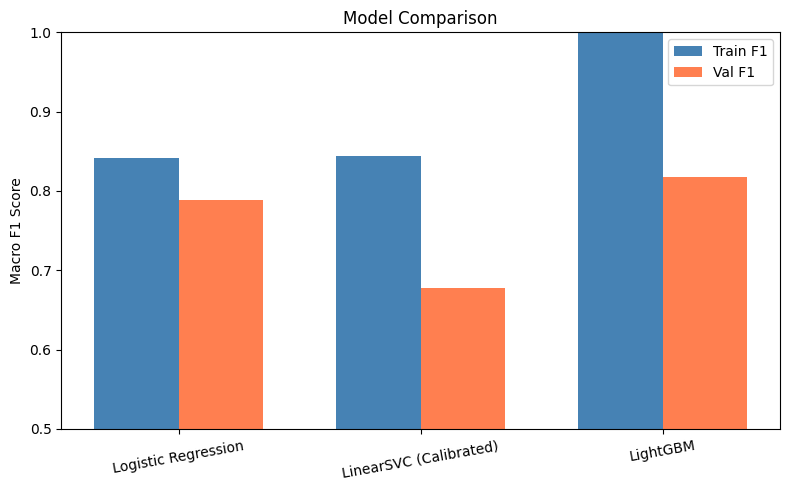

In [23]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "LinearSVC (Calibrated)", "LightGBM"],
    "Train F1": [lr_train_f1, svc_train_f1, lgbm_train_f1],
    "Val F1":   [lr_val_f1,   svc_val_f1,   lgbm_val_f1]
})

print(comparison.to_string(index=False))

plt.figure(figsize=(8,5))
x = np.arange(len(comparison))
w = 0.35
plt.bar(x - w/2, comparison["Train F1"], w, label="Train F1", color="steelblue")
plt.bar(x + w/2, comparison["Val F1"],   w, label="Val F1",   color="coral")
plt.xticks(x, comparison["Model"], rotation=10)
plt.ylabel("Macro F1 Score")
plt.title("Model Comparison")
plt.legend()
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

### Model Comparison Insights

- Logistic Regression provides a strong baseline with stable performance.
- LinearSVC underperforms, especially on minority classes.
- LightGBM achieves the highest validation F1 score.

### Observations

- LightGBM shows overfitting (high train F1 vs validation F1).
- Class imbalance affects performance, especially for class 3.
- Tree-based models handle mixed feature types better than linear models.

### Ensemble Experiment (Optional)

A soft voting ensemble of Logistic Regression, LinearSVC, and LightGBM was attempted.

However, the ensemble did not outperform LightGBM alone, so the final model selection was based on LightGBM.

In [24]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("lr", lr_model),
        ("lgbm", lgb_model)
    ],
    voting="soft",
    weights=[1, 4],   #LGBM dominates
    n_jobs=-1
)

ensemble.fit(X_train, y_train)

train_preds = ensemble.predict(X_train)
val_preds   = ensemble.predict(X_val)

ens_train_f1 = f1_score(y_train, train_preds, average="macro")
ens_val_f1   = f1_score(y_val, val_preds, average="macro")

print(f"[Ensemble] Train F1: {ens_train_f1:.4f} | Val F1: {ens_val_f1:.4f}")
print(classification_report(y_val, val_preds))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.35671064
Epoch 3, change: 0.21492462
Epoch 4, change: 0.15463122
Epoch 5, change: 0.12012101
Epoch 6, change: 0.097301345
Epoch 7, change: 0.081032669
Epoch 8, change: 0.068995569
Epoch 9, change: 0.059441261
Epoch 10, change: 0.051824653
Epoch 11, change: 0.045601492
Epoch 12, change: 0.040471707
Epoch 13, change: 0.036196766
Epoch 14, change: 0.032559832
Epoch 15, change: 0.02944322
Epoch 16, change: 0.0267838
Epoch 17, change: 0.024432633
Epoch 18, change: 0.022389634
Epoch 19, change: 0.020589407
Epoch 20, change: 0.018983354
Epoch 21, change: 0.01755996
Epoch 22, change: 0.016292056
Epoch 23, change: 0.015150066
Epoch 24, change: 0.014118366
Epoch 25, change: 0.013183777
Epoch 26, change: 0.012333791
Epoch 27, change: 0.011562242
Epoch 28, change: 0.010846411
Epoch 29, change: 0.010205439
Epoch 30, change: 0.0096021055
Epoch 31, change: 0.0090585303
Epoch 32, change: 0.0085476747
Epoch 33, change: 0.0080750583
Epoch 34, change: 0.007642003
Epo

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 1979 seconds
0.00010973905
Epoch 2949, change: 0.00010970623
Epoch 2950, change: 0.00010967262
Epoch 2951, change: 0.0001096334
Epoch 2952, change: 0.00010960181
Epoch 2953, change: 0.00010956381
Epoch 2954, change: 0.00010952607
Epoch 2955, change: 0.00010949511
Epoch 2956, change: 0.00010945738
Epoch 2957, change: 0.00010942402
Epoch 2958, change: 0.00010938832
Epoch 2959, change: 0.00010935204
Epoch 2960, change: 0.00010931693
Epoch 2961, change: 0.00010928077
Epoch 2962, change: 0.00010924792
Epoch 2963, change: 0.00010920894
Epoch 2964, change: 0.00010917564
Epoch 2965, change: 0.00010913762
Epoch 2966, change: 0.00010910563
Epoch 2967, change: 0.00010907046
Epoch 2968, change: 0.00010903399
Epoch 2969, change: 0.00010900024
Epoch 2970, change: 0.00010896771
Epoch 2971, change: 0.00010893113
Epoch 2972, change: 0.00010889389
Epoch 2973, change: 0.00010885987
Epoch 2974, change: 0.00010882384
Epoch 2975, change: 0.00010878889
Epoch 2976, change: 0.00010875604

In [25]:
# Choose best model
try:
    if ens_val_f1 > lgbm_val_f1:
        final_model = ensemble
        print("Using Ensemble Model")
    else:
        final_model = lgb_model
        print("Using LightGBM Model")
except:
    final_model = lgb_model
    print("Fallback to LightGBM")

print("Training final model on full dataset...")

final_model.fit(X, y)

print("Final model trained on full data.")

test_preds = final_model.predict(test)

submission = pd.read_csv(
    "/kaggle/input/comment-category-prediction-challenge/Sample.csv"
)

submission["label"] = test_preds
submission.to_csv("submission.csv", index=False)

print("Submission file created.")
submission.head()

Using Ensemble Model
Training final model on full dataset...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.35949896
Epoch 3, change: 0.21303528
Epoch 4, change: 0.14937936
Epoch 5, change: 0.11502256
Epoch 6, change: 0.092607926
Epoch 7, change: 0.076553541
Epoch 8, change: 0.064624685
Epoch 9, change: 0.05533582
Epoch 10, change: 0.047962518
Epoch 11, change: 0.04200359
Epoch 12, change: 0.03708282
Epoch 13, change: 0.032992642
Epoch 14, change: 0.029523733
Epoch 15, change: 0.026597179
Epoch 16, change: 0.024068509
Epoch 17, change: 0.021887241
Epoch 18, change: 0.019962551
Epoch 19, change: 0.018269233
Epoch 20, change: 0.016787656
Epoch 21, change: 0.015476842
Epoch 22, change: 0.014294594
Epoch 23, change: 0.013237654
Epoch 24, change: 0.012281631
Epoch 25, change: 0.011418025
Epoch 26, change: 0.010646838
Epoch 27, change: 0.0099306201
Epoch 28, change: 0.0092827378
Epoch 29, change: 0.0086872819
Epoch 30, change: 0.0081543387
Epoch 31, change: 0.0076487479
Epoch 32, change: 0.0071832902
Epoch 33, change: 0.0067590718
Epoch 34, change: 0.006364557

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 2632 seconds
h 2947, change: 0.00011716047
Epoch 2948, change: 0.0001171214
Epoch 2949, change: 0.00011707788
Epoch 2950, change: 0.0001170388
Epoch 2951, change: 0.00011699886
Epoch 2952, change: 0.00011695923
Epoch 2953, change: 0.00011692094
Epoch 2954, change: 0.00011688143
Epoch 2955, change: 0.00011684247
Epoch 2956, change: 0.0001168015
Epoch 2957, change: 0.00011676332
Epoch 2958, change: 0.00011672215
Epoch 2959, change: 0.00011668109
Epoch 2960, change: 0.00011664307
Epoch 2961, change: 0.00011660357
Epoch 2962, change: 0.00011656377
Epoch 2963, change: 0.00011652537
Epoch 2964, change: 0.00011648429
Epoch 2965, change: 0.00011644718
Epoch 2966, change: 0.00011640607
Epoch 2967, change: 0.00011636509
Epoch 2968, change: 0.00011632788
Epoch 2969, change: 0.00011628703
Epoch 2970, change: 0.00011624989
Epoch 2971, change: 0.00011621173
Epoch 2972, change: 0.00011617146
Epoch 2973, change: 0.00011613233
Epoch 2974, change: 0.00011609476
Epoch 2975, change:

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


## Milestone 1

In [26]:
# print("Shape of training dataset:", train.shape)

# print("Number of columns in test dataset:", test.shape[1])

# print("Number of object columns:",
#       train.select_dtypes(include="object").shape[1])

# print("Number of numerical columns:",
#       train.select_dtypes(include=["int64", "float64"]).shape[1])

# print("\nBoolean column:")
# print(train.dtypes[train.dtypes == "bool"])

# print("\nColumns with missing values:")
# print(train.isnull().sum())

# print("\nNumber of target classes:",
#       train["label"].nunique())

# print("\nPercentage distribution of labels:")
# print(train["label"].value_counts(normalize=True) * 100)

# print("\nMedian upvotes:",
#       train["upvote"].median())

# print("\nMax values of numeric features:")
# print(train[["upvote", "downvote", "if_1", "if_2"]].max())

# print("\nMinimum value of if_2:",
#       train["if_2"].min())

## Milestone-2

### 1. Missingness (NaN + empty strings)

In [27]:
# # Missing values + empty strings
# empty_comments = train["comment"].str.strip().eq("").sum()

# print("Empty/whitespace comments:", empty_comments)

### 2. Datetime + Most frequent month

In [28]:
# train["created_date"] = pd.to_datetime(train["created_date"])

# most_common_month = (
#     train["created_date"]
#     .dt.month_name()
#     .str.lower()
#     .value_counts()
#     .idxmax()
# )

# print("Most frequent month:", most_common_month)

### 3. Emoticon feature

In [29]:
# train["total_emoticons"] = (
#     train["emoticon_1"] +
#     train["emoticon_2"] +
#     train["emoticon_3"]
# )

# print("Max total_emoticons:", train["total_emoticons"].max())

### 4. Comment length (label = 3)

In [30]:
# train["comment"] = train["comment"].fillna("")
# train["char_length"] = train["comment"].apply(len)

# median_len_label3 = train[train["label"] == 3]["char_length"].median()

# print("Median char length (label=3):", median_len_label3)

### 5. Min-Max scaling (upvote = 10)

In [31]:
# min_val = train["upvote"].min()
# max_val = train["upvote"].max()

# scaled_10 = (10 - min_val) / (max_val - min_val)

# print("Scaled value for 10 upvotes:", scaled_10)

### 6. Word count (label = 1)

In [32]:
# train["word_count"] = train["comment"].apply(lambda x: len(str(x).split()))

# avg_word_count = round(
#     train[train["label"] == 1]["word_count"].mean(), 2
# )

# print("Avg word count (label=1):", avg_word_count)

### 7. "Trump" occurrences

In [33]:
# trump_count = train["comment"].str.contains(
#     "trump", case=False, na=False
# ).sum()

# print("Comments containing 'Trump':", trump_count)

### 8. Text cleaning (row 0)

In [34]:
# import re

# text = str(train.loc[0, "comment"])

# # Remove punctuation
# text = re.sub(r"[^\w\s]", "", text)

# stop_words = ['a','an','the','and','or','but','if','because','as','of','at','by',
#               'for','with','about','to','from','up','on','in','out','over','under',
#               'is','are','was','were','be','been','being','have','has','had','do',
#               'does','did','it','its','they','them','their','she','her','he','him',
#               'his','this','that','which','who','whom','i','me','my','we','our',
#               'you','your']

# tokens = text.lower().split()
# filtered = [w for w in tokens if w not in stop_words]

# print("Words left after cleaning:", len(filtered))

### 9. Unique tokens

In [35]:
# all_tokens = set()

# for text in train["comment"].fillna("").str.lower():
#     all_tokens.update(text.split())

# print("Total unique tokens:", len(all_tokens))

### 10. TF-IDF feature count

In [36]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     stop_words="english",
#     min_df=5,
#     ngram_range=(1, 2)
# )

# X_tfidf = tfidf.fit_transform(train["comment"].fillna(""))

# print("Number of TF-IDF features:", X_tfidf.shape[1])

## Milestone-3

In [37]:
# import pandas as pd
# import numpy as np

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# print("head:")
# print(train.head())
# print("shape:")
# print(train.shape)
# print("info:")
# print(train.info())
# print("sum:")
# print(train.isnull().sum())
# print("dtype:")
# print(train.dtypes)
# train.select_dtypes(include="object").columns
# train.select_dtypes(include=["int64","float64"]).columns

In [38]:
# train["label"].nunique()

In [39]:
# train["label"].value_counts(normalize=True) * 100

In [40]:
# train["upvote"].median()

In [41]:
# train[["upvote","downvote","if_1","if_2"]].max()

In [42]:
# train["if_2"].min()

In [43]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.countplot(x="label", data=train)
# plt.title("Label Distribution")
# plt.show()

In [44]:
# train[["upvote","downvote"]].describe()

In [45]:
# sns.histplot(train["upvote"], bins=50)
# plt.show()

In [46]:
# train["comment_length"] = train["comment"].fillna("").apply(len)

# sns.histplot(train["comment_length"], bins=50)
# plt.title("Comment Length Distribution")
# plt.show()

In [47]:
# from sklearn.model_selection import train_test_split

# train["comment"] = train["comment"].fillna("")
# test["comment"] = test["comment"].fillna("")

# X = train.drop("label", axis=1)
# y = train["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

In [48]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     max_features=5000,
#     stop_words="english"
# )

# X_train_text = tfidf.fit_transform(X_train["comment"])
# X_val_text = tfidf.transform(X_val["comment"])

In [49]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

# model = LogisticRegression(max_iter=1000)

# model.fit(X_train_text, y_train)

# val_preds = model.predict(X_val_text)

# accuracy_score(y_val, val_preds)

In [50]:
# import re

# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"[^a-zA-Z\s]", "", text)
#     return text

# train["comment"] = train["comment"].apply(clean_text)

In [51]:
# train["created_date"] = pd.to_datetime(train["created_date"])

# train["month"] = train["created_date"].dt.month_name()

# train["month"].value_counts()

In [52]:
# train["month"].value_counts().idxmax().lower()

In [53]:
# train["total_emoticons"] = (
#     train["emoticon_1"] +
#     train["emoticon_2"] +
#     train["emoticon_3"]
# )

# train["total_emoticons"].max()

In [54]:
# train["comment"] = train["comment"].fillna("")

# train["char_length"] = train["comment"].apply(len)

# train[train["label"] == 3]["char_length"].median()

In [55]:
# min_val = train["upvote"].min()
# max_val = train["upvote"].max()
# print("min =",min_val, "max =", max_val)
# scaled_10 = (10 - min_val) / (max_val - min_val)
# scaled_10

In [56]:
# train["word_count"] = train["comment"].apply(lambda x: len(str(x).split()))

# round(
#     train[train["label"] == 1]["word_count"].mean(),
#     2
# )

In [57]:
# train["comment"].str.contains("trump", case=False, na=False).sum()

In [58]:
# import re

# text = str(train.loc[0, "comment"])

# # Remove punctuation
# text = re.sub(r"[^\w\s]", "", text)

# stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as',
#               'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up',
#               'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were',
#               'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does',
#               'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her',
#               'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom',
#               'i', 'me', 'my', 'we', 'our', 'you', 'your']

# tokens = text.lower().split()

# filtered = [word for word in tokens if word not in stop_words]

# len(filtered)

In [59]:
# all_tokens = set()

# for text in train["comment"].fillna("").str.lower():
#     all_tokens.update(text.split())

# len(all_tokens)

In [60]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     stop_words="english",
#     min_df=5,
#     ngram_range=(1,2)
# )

# X_tfidf = tfidf.fit_transform(train["comment"].fillna(""))

# X_tfidf.shape

In [61]:
# from sklearn.model_selection import train_test_split

# X = train.drop("label", axis=1)
# y = train["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )

# a = X_train.shape[0]
# c = X_val.shape[0]

# a + c

In [62]:
# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# X_val["created_date"] = pd.to_datetime(X_val["created_date"])

# X_train["day"] = X_train["created_date"].dt.day
# X_train["month"] = X_train["created_date"].dt.month_name()
# X_train["year"] = X_train["created_date"].dt.year

# X_val["day"] = X_val["created_date"].dt.day
# X_val["month"] = X_val["created_date"].dt.month_name()
# X_val["year"] = X_val["created_date"].dt.year

# X_train["month"].value_counts().idxmax().lower()

In [63]:
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder

# categorical_cols = ["religion", "gender", "race"]

# # Impute
# imputer = SimpleImputer(strategy="constant", fill_value="none")

# X_train[categorical_cols] = imputer.fit_transform(X_train[categorical_cols])
# X_val[categorical_cols] = imputer.transform(X_val[categorical_cols])

# # One Hot Encode
# encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# encoded_train = encoder.fit_transform(X_train[categorical_cols])
# encoded_val = encoder.transform(X_val[categorical_cols])

# encoded_train_df = pd.DataFrame(
#     encoded_train,
#     columns=encoder.get_feature_names_out(categorical_cols),
#     index=X_train.index
# )

# encoded_val_df = pd.DataFrame(
#     encoded_val,
#     columns=encoder.get_feature_names_out(categorical_cols),
#     index=X_val.index
# )

# # Drop old columns and concatenate
# X_train = pd.concat(
#     [X_train.drop(columns=categorical_cols), encoded_train_df],
#     axis=1
# )

# X_val = pd.concat(
#     [X_val.drop(columns=categorical_cols), encoded_val_df],
#     axis=1
# )

# X_train.shape[1]

In [64]:
# from sklearn.feature_extraction.text import CountVectorizer

# vectorizer = CountVectorizer()

# X_train["comment"] = X_train["comment"].fillna("")
# X_val["comment"] = X_val["comment"].fillna("")

# X_train_counts = vectorizer.fit_transform(X_train["comment"])
# X_val_counts = vectorizer.transform(X_val["comment"])

# X_train_counts[1].sum()

In [65]:
# X_train["disability"] = X_train["disability"].astype(int)
# X_val["disability"] = X_val["disability"].astype(int)

# X_train["disability"].sum() + X_val["disability"].sum()

In [66]:
# from sklearn.preprocessing import StandardScaler

# numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns

# scaler = StandardScaler()

# scaler.fit(X_train[numeric_cols])

# len(scaler.feature_names_in_)

In [67]:
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.metrics import f1_score
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
# import numpy as np

# # Reset raw data
# X = train.drop("label", axis=1)
# y = train["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Datetime features
# for df in [X_train, X_val]:
#     df["created_date"] = pd.to_datetime(df["created_date"])
#     df["day"] = df["created_date"].dt.day
#     df["month"] = df["created_date"].dt.month
#     df["year"] = df["created_date"].dt.year
#     df.drop(columns=["created_date"], inplace=True)

# # Impute negatives safeguard
# num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
# imputer = SimpleImputer(strategy="median")

# X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
# X_val[num_cols] = imputer.transform(X_val[num_cols])

# X_train[num_cols] = np.abs(X_train[num_cols])
# X_val[num_cols] = np.abs(X_val[num_cols])

# # ColumnTransformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("tfidf", TfidfVectorizer(stop_words="english"), "comment"),
#         ("cat", OneHotEncoder(handle_unknown="ignore"), 
#          X_train.select_dtypes(include=["object","bool"]).columns),
#         ("num", "passthrough", num_cols)
#     ]
# )

# model = Pipeline([
#     ("preprocess", preprocessor),
#     ("clf", MultinomialNB())
# ])

# model.fit(X_train, y_train)

# train_preds = model.predict(X_train)
# val_preds = model.predict(X_val)

# round(f1_score(y_train, train_preds, average="macro"), 4), \
# round(f1_score(y_val, val_preds, average="macro"), 4)

In [68]:
# # Fresh split
# X = train.drop("label", axis=1)
# y = train["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# for df in [X_train, X_val]:
#     df["created_date"] = pd.to_datetime(df["created_date"])

#     # Extract features
#     df["day"] = df["created_date"].dt.day
#     df["month"] = df["created_date"].dt.month
#     df["year"] = df["created_date"].dt.year

#     # Create weekend feature BEFORE dropping
#     df["is_weekend"] = (df["created_date"].dt.dayofweek >= 5).astype(int)

#     # Now drop original column
#     df.drop(columns=["created_date"], inplace=True)

# Milestone 4

In [69]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# train["comment"] = train["comment"].fillna("")

# X = train.drop("label", axis=1)
# y = train["label"]

In [70]:
# X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
#     X, y,
#     test_size=0.4,
#     random_state=2306,
#     stratify=y
# )

# train_counts_A = y_train_A.value_counts().sort_index().values
# val_counts_A = y_val_A.value_counts().sort_index().values

In [71]:
# X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(
#     X, y,
#     test_size=0.4,
#     random_state=2306,
#     stratify=None
# )

# train_counts_B = y_train_B.value_counts().sort_index().values
# val_counts_B = y_val_B.value_counts().sort_index().values

In [72]:
# val_prop_A = val_counts_A / val_counts_A.sum()
# val_prop_B = val_counts_B / val_counts_B.sum()

# diff = np.abs(val_prop_A - val_prop_B)

# np.max(diff)

In [73]:
# x_train, x_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.4,
#     random_state=2306,
#     stratify=y
# )

In [74]:
# x_train = x_train.drop(columns=["created_date"])
# x_test = x_test.drop(columns=["created_date"])

In [75]:
# text_x_train = x_train["comment"]
# text_x_test = x_test["comment"]

# x_train = x_train.drop(columns=["comment"])
# x_test = x_test.drop(columns=["comment"])

In [76]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline

# cat_cols = ["race", "religion", "gender", "disability"]

# num_cols = [
# "post_id","emoticon_1","emoticon_2","emoticon_3",
# "upvote","downvote","if_1","if_2"
# ]

# cat_pipe = Pipeline([
# ("imputer", SimpleImputer(strategy="most_frequent")),
# ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

# num_pipe = Pipeline([
# ("imputer", SimpleImputer(strategy="mean")),
# ("scaler", StandardScaler())
# ])

# preprocessor = ColumnTransformer(
# [
# ("cat", cat_pipe, cat_cols),
# ("num", num_pipe, num_cols)
# ],
# remainder="passthrough"
# )

In [77]:
# x_train_tabular = preprocessor.fit_transform(x_train)
# x_test_tabular = preprocessor.transform(x_test)

In [78]:
# import re

# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text

# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm = text_x_test.apply(normalize_text)

In [79]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

# tf_idf_train = vectorizer.fit_transform(text_x_train_norm)
# tf_idf_test = vectorizer.transform(text_x_test_norm)

In [80]:
# from scipy.sparse import hstack

# X_train_final = hstack([x_train_tabular, tf_idf_train])
# X_test_final = hstack([x_test_tabular, tf_idf_test])

In [81]:
# X_train_final.sum()

In [82]:
# from sklearn.decomposition import TruncatedSVD

# svd = TruncatedSVD(n_components=300, random_state=2306)

# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced = svd.transform(X_test_final)

In [83]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestClassifier(random_state=2306)

# param_dist = {
# "n_estimators":[50,100,200],
# "max_depth":[5,10,15]
# }

# randomized_search = RandomizedSearchCV(
# rf,
# param_dist,
# n_iter=5,
# cv=3,
# random_state=2306,
# n_jobs=-1
# )

# randomized_search.fit(X_train_reduced, y_train)

# randomized_search.best_params_

In [84]:
# from sklearn.ensemble import AdaBoostClassifier
# import numpy as np

# model = AdaBoostClassifier(
# n_estimators=50,
# random_state=2306
# )

# model.fit(X_train_reduced, y_train)

# round(np.var(model.estimator_errors_),4)

In [85]:
# rf = RandomForestClassifier(
# n_estimators=100,
# max_depth=10,
# random_state=2306
# )

# rf.fit(X_train_reduced, y_train)

# np.argmax(rf.feature_importances_)

In [86]:
# N = X_train_reduced.shape[1]

# weights = (
# N*128 +
# 128*64 +
# 64*32 +
# 32*4
# )

# weights

In [87]:
# from sklearn.neural_network import MLPClassifier

# mlp = MLPClassifier(
# hidden_layer_sizes=(128,64,32),
# activation="relu",
# solver="adam",
# max_iter=5,
# batch_size=32,
# random_state=2306
# )

# mlp.fit(X_train_reduced, y_train)

# round(mlp.loss_,4)

In [88]:
# from sklearn.metrics import f1_score

# modelA = MLPClassifier(
# hidden_layer_sizes=(100,),
# max_iter=5,
# random_state=2306
# )

# modelB = MLPClassifier(
# hidden_layer_sizes=(100,),
# alpha=1.0,
# max_iter=5,
# random_state=2306
# )

# modelA.fit(X_train_reduced,y_train)
# modelB.fit(X_train_reduced,y_train)

# predA = modelA.predict(X_train_reduced)
# predB = modelB.predict(X_train_reduced)

# scoreA = f1_score(y_train,predA,average="macro")
# scoreB = f1_score(y_train,predB,average="macro")

# round(abs(scoreA-scoreB),4)

In [89]:
# from sklearn.metrics import confusion_matrix

# mlp = MLPClassifier(
# hidden_layer_sizes=(128,64,32),
# solver="adam",
# max_iter=5,
# batch_size=32,
# random_state=2306
# )

# mlp.fit(X_train_reduced,y_train)

# val_pred = mlp.predict(X_test_reduced)

# cm = confusion_matrix(y_test,val_pred)

# off_diag = cm.sum() - np.trace(cm)

# round(off_diag/cm.sum(),4)